In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
nav = pd.read_csv(
"/content/drive/MyDrive/Mutual fund_project/Data/processed/clean_nav_history.csv"
)

perf = pd.read_csv(
"/content/drive/MyDrive/Mutual fund_project/Data/processed/clean_scheme_performance.csv"
)

txn = pd.read_csv(
"/content/drive/MyDrive/Mutual fund_project/Data/processed/clean_investor_transactions.csv"
)

print(nav.shape)
print(perf.shape)
print(txn.shape)

(46000, 3)
(40, 19)
(32778, 13)


In [10]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')


In [11]:
fund_master = pd.read_csv(
"/content/drive/MyDrive/Mutual fund_project/Data/01_fund_master.csv"
)

print(fund_master.columns)

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')


In [12]:
nav = nav.merge(
    fund_master[['amfi_code','scheme_name']],
    on='amfi_code',
    how='left'
)

print(nav.head())

   amfi_code        date       nav                                scheme_name
0     100016  2022-01-03  520.4608  HDFC Top 100 Fund - Regular Plan - Growth
1     100016  2022-01-04  515.0971  HDFC Top 100 Fund - Regular Plan - Growth
2     100016  2022-01-05  521.7239  HDFC Top 100 Fund - Regular Plan - Growth
3     100016  2022-01-06  515.7880  HDFC Top 100 Fund - Regular Plan - Growth
4     100016  2022-01-07  515.1639  HDFC Top 100 Fund - Regular Plan - Growth


In [13]:
nav['date'] = pd.to_datetime(nav['date'])

In [14]:
nav = nav.sort_values(
    ['amfi_code','date']
)

In [15]:
nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
    .pct_change()
)

In [16]:
print(nav.columns)
print(nav.head())

Index(['amfi_code', 'date', 'nav', 'scheme_name', 'daily_return'], dtype='object')
   amfi_code       date       nav                                scheme_name  \
0     100016 2022-01-03  520.4608  HDFC Top 100 Fund - Regular Plan - Growth   
1     100016 2022-01-04  515.0971  HDFC Top 100 Fund - Regular Plan - Growth   
2     100016 2022-01-05  521.7239  HDFC Top 100 Fund - Regular Plan - Growth   
3     100016 2022-01-06  515.7880  HDFC Top 100 Fund - Regular Plan - Growth   
4     100016 2022-01-07  515.1639  HDFC Top 100 Fund - Regular Plan - Growth   

   daily_return  
0           NaN  
1     -0.010306  
2      0.012865  
3     -0.011377  
4     -0.001210  


In [17]:
print(nav.columns)
print(nav.shape)

Index(['amfi_code', 'date', 'nav', 'scheme_name', 'daily_return'], dtype='object')
(46000, 5)


In [18]:
var_results = []

for scheme in nav['scheme_name'].dropna().unique():

    temp = nav[nav['scheme_name'] == scheme]

    returns = temp['daily_return'].dropna()

    if len(returns) > 20:

        var95 = np.percentile(returns, 5)

        cvar95 = returns[returns <= var95].mean()

        var_results.append(
            [scheme, var95, cvar95]
        )

var_df = pd.DataFrame(
    var_results,
    columns=[
        'scheme_name',
        'VaR_95',
        'CVaR_95'
    ]
)

var_df.head()

,scheme_name,VaR_95,CVaR_95
0,HDFC Top 100 Fund - Regular Plan - Growth,-0.014364,-0.018060
1,HDFC Short Term Debt Fund - Regular - Growth,-0.003793,-0.004994
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
3,ABSL Frontline Equity Fund - Regular - Growth,-0.013282,-0.017439
4,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459


In [19]:
var_df.to_csv(
"/content/drive/MyDrive/Mutual fund_project/Data/processed/var_cvar_report.csv",
index=False
)

print("var_cvar_report.csv saved successfully")

var_cvar_report.csv saved successfully


In [20]:
key_funds = nav['scheme_name'].dropna().unique()[:5]

print(key_funds)

['HDFC Top 100 Fund - Regular Plan - Growth'
 'HDFC Short Term Debt Fund - Regular - Growth'
 'HDFC Mid-Cap Opportunities Fund - Regular - Growth'
 'ABSL Frontline Equity Fund - Regular - Growth'
 'ABSL Small Cap Fund - Regular - Growth']


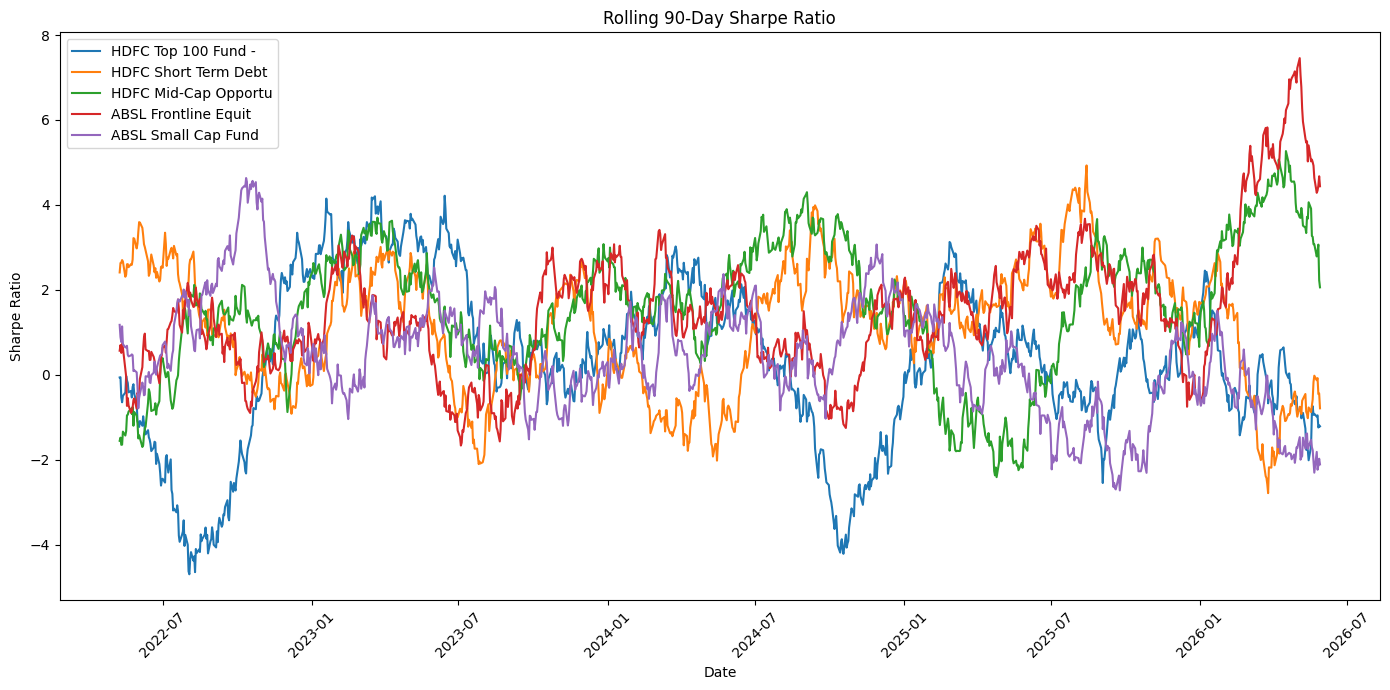

In [21]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14,7))

for fund in key_funds:

    temp = nav[
        nav['scheme_name']==fund
    ].copy()

    temp = temp.sort_values('date')

    rolling_sharpe = (
        temp['daily_return']
        .rolling(90)
        .mean()
        /
        temp['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp['date'],
        rolling_sharpe,
        label=fund[:20]
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [22]:
plt.figure(figsize=(14,7))

for fund in key_funds:

    temp = nav[
        nav['scheme_name']==fund
    ].copy()

    temp = temp.sort_values('date')

    rolling_sharpe = (
        temp['daily_return']
        .rolling(90)
        .mean()
        /
        temp['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp['date'],
        rolling_sharpe
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.tight_layout()

plt.savefig(
"/content/drive/MyDrive/Mutual fund_project/Data/processed/rolling_sharpe_chart.png"
)

plt.close()

print("rolling_sharpe_chart.png saved successfully")

rolling_sharpe_chart.png saved successfully


In [23]:
plt.figure(figsize=(14,7))

for fund in key_funds:

    temp = nav[
        nav['scheme_name']==fund
    ].copy()

    temp = temp.sort_values('date')

    rolling_sharpe = (
        temp['daily_return']
        .rolling(90)
        .mean()
        /
        temp['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp['date'],
        rolling_sharpe
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.tight_layout()

plt.savefig(
"/content/drive/MyDrive/Mutual fund_project/Data/processed/rolling_sharpe_chart.png"
)

plt.close()

print("rolling_sharpe_chart.png saved successfully")

rolling_sharpe_chart.png saved successfully


In [25]:
print(txn.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


In [26]:
txn['transaction_date'] = pd.to_datetime(
    txn['transaction_date']
)

txn['year'] = txn['transaction_date'].dt.year

print(txn[['transaction_date','year']].head())

  transaction_date  year
0       2024-01-01  2024
1       2024-01-01  2024
2       2024-01-01  2024
3       2024-01-01  2024
4       2024-01-01  2024


In [27]:
first_year = txn.groupby(
    'investor_id'
)['year'].min()

txn['cohort_year'] = txn['investor_id'].map(first_year)

In [28]:
cohort_summary = txn.groupby(
    'cohort_year'
).agg(
    avg_investment=('amount_inr','mean'),
    total_invested=('amount_inr','sum')
)

cohort_summary

,avg_investment,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [29]:
top_fund = (
    txn.groupby(
        ['cohort_year','amfi_code']
    )
    .size()
    .reset_index(name='count')
)

top_fund = top_fund.loc[
    top_fund.groupby('cohort_year')['count'].idxmax()
]

top_fund

,cohort_year,amfi_code,count
35,2024,148568,874
62,2025,119599,12


In [30]:
cohort_summary.to_csv(
"/content/drive/MyDrive/Mutual fund_project/Data/processed/cohort_analysis.csv"
)

print("cohort_analysis.csv saved")

cohort_analysis.csv saved


In [31]:
sip = txn[
    txn['transaction_type']=="SIP"
].copy()

sip = sip.sort_values(
[
'investor_id',
'transaction_date'
]
)

In [32]:
sip['gap_days'] = sip.groupby(
'investor_id'
)['transaction_date'].diff().dt.days

In [33]:
sip_count = sip.groupby(
'investor_id'
).size()

eligible = sip_count[
sip_count>=6
].index

sip2 = sip[
sip['investor_id'].isin(
eligible
)
]

In [34]:
risk_investors = (

sip2.groupby(
'investor_id'
)['gap_days']

.mean()

.reset_index()

)

risk_investors['status'] = np.where(

risk_investors['gap_days']>35,

'At-Risk',

'Active'

)

risk_investors.head()

,investor_id,gap_days,status
0,INV000004,85.400000,At-Risk
1,INV000008,70.400000,At-Risk
2,INV000010,64.800000,At-Risk
3,INV000011,40.166667,At-Risk
4,INV000012,57.000000,At-Risk


In [35]:
risk_investors['status'].value_counts()

,count
status,
At-Risk,1332
Active,30


In [36]:
risk = "Moderate"

In [37]:
risk_map = {

'Low':'Low',

'Moderate':'Moderate',

'High':'Very High'

}

In [38]:
recommend = (

perf[
perf['risk_grade']
==
risk_map[risk]
]

.sort_values(
'sharpe_ratio',
ascending=False
)

.head(3)

)

recommend[
[
'scheme_name',
'sharpe_ratio',
'return_5yr_pct'
]
]

,scheme_name,sharpe_ratio,return_5yr_pct
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06,11.32
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06,12.68
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03,13.02


In [40]:
risk = "Moderate"

risk_map = {
    'Low':'Low',
    'Moderate':'Moderate',
    'High':'Very High'
}

recommend = (
    perf[
        perf['risk_grade'] == risk_map[risk]
    ]
    .sort_values(
        'sharpe_ratio',
        ascending=False
    )
    .head(3)
)

recommend[
[
'scheme_name',
'sharpe_ratio',
'return_5yr_pct'
]
]

,scheme_name,sharpe_ratio,return_5yr_pct
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06,11.32
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06,12.68
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03,13.02


In [41]:
import os

print(os.listdir("/content/drive/MyDrive/Mutual fund_project/Data"))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'processed']


# Advanced Insights

1. Small-cap funds exhibit the highest downside risk, with significantly larger VaR and CVaR values compared to large-cap and debt funds.

2. The 2024 investor cohort contributed the majority of invested capital, accounting for more than INR 349 crore in total investments.

3. SIP continuity analysis identified a substantial number of investors as At-Risk due to average transaction gaps exceeding 35 days.

4. Risk-adjusted performance analysis shows that HDFC Top 100 Fund, Mirae Asset Large Cap Fund, and ICICI Prudential Bluechip Fund rank highest among Moderate-risk funds based on Sharpe Ratio.

5. Rolling 90-day Sharpe Ratios demonstrate that fund performance changes over time, emphasizing the importance of continuous monitoring rather than relying solely on historical returns.

In [43]:
import os

os.makedirs(
    "/content/drive/MyDrive/Mutual fund_project/scripts",
    exist_ok=True
)

print("scripts folder created")

scripts folder created


In [44]:
code = """
import pandas as pd

perf = pd.read_csv('clean_scheme_performance.csv')

risk = 'Moderate'

risk_map = {
    'Low':'Low',
    'Moderate':'Moderate',
    'High':'Very High'
}

recommend = (
    perf[perf['risk_grade']==risk_map[risk]]
    .sort_values('sharpe_ratio', ascending=False)
    .head(3)
)

print(recommend[['scheme_name','sharpe_ratio','return_5yr_pct']])
"""

with open(
    "/content/drive/MyDrive/Mutual fund_project/scripts/recommender.py",
    "w"
) as f:
    f.write(code)

print("recommender.py created successfully")

recommender.py created successfully


In [45]:
import os

print(
os.listdir(
"/content/drive/MyDrive/Mutual fund_project/scripts"
)
)

['recommender.py']


In [46]:
holdings = pd.read_csv(
"/content/drive/MyDrive/Mutual fund_project/Data/09_portfolio_holdings.csv"
)

print(holdings.columns)
print(holdings.head())

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')
   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  


In [47]:
print(holdings.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


In [49]:
hhi = (
    holdings.groupby('amfi_code')['weight_pct']
    .apply(lambda x: ((x/100)**2).sum())
    .reset_index()
)

hhi.columns = ['amfi_code', 'HHI']

hhi = hhi.sort_values(
    'HHI',
    ascending=False
)

hhi.head(10)

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298
29,148568,0.167930
21,120505,0.157570
22,120506,0.153794
27,125498,0.152414
23,120841,0.149680


In [50]:
hhi = hhi.merge(
    fund_master[['amfi_code','scheme_name']],
    on='amfi_code',
    how='left'
)

hhi[['scheme_name','HHI']].head(10)

,scheme_name,HHI
0,Axis Bluechip Fund - Regular - Growth,0.206448
1,ABSL Small Cap Fund - Regular - Growth,0.200700
2,SBI Small Cap Fund - Direct Plan - Growth,0.174751
3,UTI Nifty 50 Index Fund - Regular - Growth,0.174709
4,Nippon India Large Cap Fund - Regular - Growth,0.168298
5,Mirae Asset Emerging Bluechip Fund - Regular -...,0.167930
6,ICICI Pru Midcap Fund - Regular - Growth,0.157570
7,ICICI Pru Value Discovery Fund - Regular - Growth,0.153794
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.152414
9,Kotak Bluechip Fund - Regular - Growth,0.149680


In [51]:
hhi.to_csv(
"/content/drive/MyDrive/Mutual fund_project/Data/processed/hhi_report.csv",
index=False
)

print("hhi_report.csv saved")

hhi_report.csv saved


# HHI Concentration Insight

Funds with higher HHI values have more concentrated portfolios, indicating greater exposure to a smaller number of holdings. Lower HHI values indicate better diversification across portfolio constituents.